# POC simulation v3 — two-instrument G-estimation with mediation, \(L\), and \(U\)

This simulation follows the causal graph

$$
Z_1 \rightarrow A,\qquad
Z_2 \rightarrow M,\qquad
A \rightarrow M \rightarrow Y,\qquad
A \rightarrow Y,
$$

with measured confounding by \(L\) and unmeasured confounding by \(U\):

$$
L \rightarrow (A,M,Y),
\qquad
U \rightarrow (A,M,Y).
$$

The variables are:

- \(A\): binary treatment or exposure.
- \(M\): binary mediator.
- \(Y\): binary outcome.
- \(L\): measured confounder.
- \(U\): unmeasured confounder.
- \(Z_1\): instrument for \(A\).
- \(Z_2\): instrument for \(M\).

The notebook compares the DGM-based Monte Carlo truth with crude estimation, naive G-computation, and a two-instrument G-estimation prototype. All causal effects are first calculated on the risk-difference scale and are then transformed into signed NNT measures.

The mediation decomposition is

$$
RD_{\mathrm{total}}
=
RD_{\mathrm{direct}}
+
RD_{\mathrm{indirect}}.
$$

$$
\frac{1}{NNT_{\mathrm{total}}}
=
\frac{1}{NNT_{\mathrm{direct}}}
+
\frac{1}{NNT_{\mathrm{indirect}}}.
$$

The IV/G-estimation section is a simulation prototype and should not be interpreted as a complete formal identification proof.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy.special import expit
from scipy.optimize import root, root_scalar
import statsmodels.api as sm

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

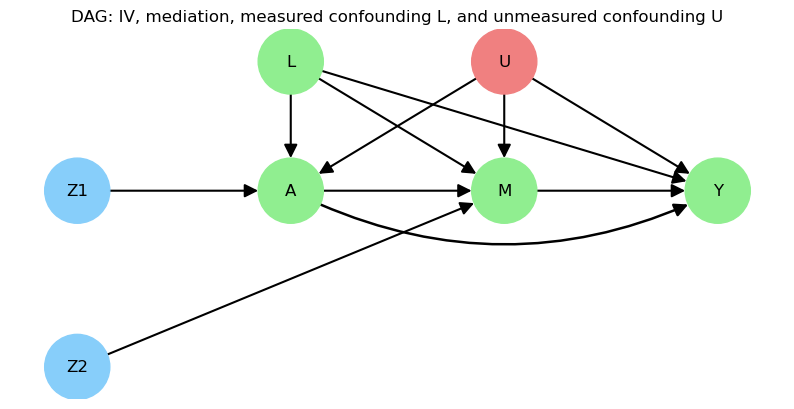

In [2]:

def draw_dag():
    G = nx.DiGraph()

    edges = [
        ("Z1", "A"), ("Z2", "M"),
        ("L", "A"), ("L", "M"), ("L", "Y"),
        ("U", "A"), ("U", "M"), ("U", "Y"),
        ("A", "M"),
        ("M", "Y")
    ]

    curved_edges = [
        ("A", "Y")
    ]

    G.add_edges_from(edges + curved_edges)

    pos = {
        "Z1": (0.0, 1.5),
        "Z2": (0.0, 0.0),

        "L": (2.0, 2.6),
        "A": (2.0, 1.5),

        "U": (4.0, 2.6),
        "M": (4.0, 1.5),

        "Y": (6.0, 1.5),
    }

    colors = {
        "Z1": "lightskyblue",
        "Z2": "lightskyblue",
        "U": "lightcoral"
    }

    node_colors = [colors.get(n, "lightgreen") for n in G.nodes()]

    plt.figure(figsize=(10, 4.8))

    # Draw nodes
    nx.draw_networkx_nodes(
        G, pos,
        node_color=node_colors,
        node_size=2200
    )

    # Draw labels
    nx.draw_networkx_labels(
        G, pos,
        font_size=12
    )

    # Draw regular edges
    nx.draw_networkx_edges(
        G, pos,
        edgelist=edges,
        arrows=True,
        arrowsize=20,
        width=1.5,
        node_size=2200,
        connectionstyle="arc3,rad=0.0"
    )

    # Draw curved A -> Y edge
    nx.draw_networkx_edges(
        G, pos,
        edgelist=curved_edges,
        arrows=True,
        arrowsize=20,
        width=1.8,
        node_size=2200,
        connectionstyle="arc3,rad=0.25"
    )

    plt.title("DAG: IV, mediation, measured confounding L, and unmeasured confounding U")
    plt.axis("off")
    plt.show()


draw_dag()

## Data-generating mechanism

The baseline variables are generated as

$$
Z_1 \sim \operatorname{Bernoulli}(0.5),
\qquad
Z_2 \sim \operatorname{Bernoulli}(0.5),
$$

$$
L \sim \mathcal{N}(0.5,0.5^2),
\qquad
U \sim \mathcal{N}(0,1).
$$

When `with_u=True`, the structural equations are

$$
\operatorname{logit}
\Pr(A=1\mid Z_1,L,U)
=
-1.0
+1.4Z_1
+0.6L
+0.9U,
$$

$$
\operatorname{logit}
\Pr(M=1\mid A,Z_2,L,U)
=
-1.6
+1.2A
+1.3Z_2
+0.5L
+0.8U,
$$

$$
\operatorname{logit}
\Pr(Y=1\mid A,M,L,U)
=
-3.0
+0.8A
+1.4M
-0.7L
+1.1U.
$$

Equivalently, with $$\operatorname{expit}(x)=1/(1+e^{-x}) $$

$$
A \sim \operatorname{Bernoulli}(p_A),
\qquad
M \sim \operatorname{Bernoulli}(p_M),
\qquad
Y \sim \operatorname{Bernoulli}(p_Y),
$$

where $$ {p}_A, \qquad {p}_M, \qquad {p}_Y$$ are obtained by applying the expit function to the corresponding linear predictors.

When `with_u=False`, the coefficients multiplying \(U\) are set to zero. Measured confounding through \(L\) remains present in both scenarios.

The instruments are designed to satisfy relevance through the paths

$$
Z_1 \rightarrow A,
\qquad
Z_2 \rightarrow M,
$$

while neither instrument enters the structural outcome equation directly.


In [3]:
DGM = {
    "A": {"intercept": -1.0, "Z1": 1.4, "L": 0.6, "U": 0.9},
    "M": {"intercept": -1.6, "A": 1.2, "Z2": 1.3, "L": 0.5, "U": 0.8},
    "Y": {"intercept": -3.0, "A": 0.8, "M": 1.4, "L": -0.7, "U": 1.1},
}


def simulate_data(N=5000, with_u=True, seed=None):
    rng = np.random.default_rng(seed)

    Z1 = rng.binomial(1, 0.5, N) # 0 or 1
    Z2 = rng.binomial(1, 0.5, N) # 0 or 1
    L = rng.normal(0.5, 0.5, N)
    U = rng.normal(0, 1, N)

    uA = DGM["A"]["U"] if with_u else 0.0
    uM = DGM["M"]["U"] if with_u else 0.0
    uY = DGM["Y"]["U"] if with_u else 0.0

    # Stractural Equations
    pA = expit(DGM["A"]["intercept"] + DGM["A"]["Z1"] * Z1 + DGM["A"]["L"] * L + uA * U)
    A = rng.binomial(1, pA)

    pM = expit(DGM["M"]["intercept"] + DGM["M"]["A"] * A + DGM["M"]["Z2"] * Z2 + DGM["M"]["L"] * L + uM * U)
    M = rng.binomial(1, pM)

    pY = expit(DGM["Y"]["intercept"] + DGM["Y"]["A"] * A + DGM["Y"]["M"] * M + DGM["Y"]["L"] * L + uY * U)
    Y = rng.binomial(1, pY)

    return pd.DataFrame({"Z1": Z1, "Z2": Z2, "L": L, "U": U, "A": A, "M": M, "Y": Y})


def nnt_from_rd(rd, eps=1e-8):
    if abs(rd) < eps:
        return np.nan
    return 1.0 / rd


def add_nnt_cols(out):
    return {
        **out,
        "total_nnt": nnt_from_rd(out["total_rd"]),
        "direct_nnt": nnt_from_rd(out["direct_rd"]),
        "indirect_nnt": nnt_from_rd(out["indirect_rd"]),
    }

## True total, direct, and indirect effects

Let \(M(a)\) denote the mediator under treatment level \(a\), and let \(Y(a,m)\) denote the outcome under treatment \(a\) and mediator value \(m\).

The three counterfactual risks required for the mediation decomposition are

$$
R_{11}
=
\mathbb{E}\!\left[Y\{1,M(1)\}\right],
$$

$$
R_{00}
=
\mathbb{E}\!\left[Y\{0,M(0)\}\right],
$$

$$
R_{10}
=
\mathbb{E}\!\left[Y\{1,M(0)\}\right].
$$

The total, natural direct, and natural indirect effects on the risk-difference scale are

$$
\begin{aligned}
RD_{\mathrm{total}}
&=
R_{11}-R_{00},\\
RD_{\mathrm{direct}}
&=
R_{10}-R_{00},\\
RD_{\mathrm{indirect}}
&=
R_{11}-R_{10}.
\end{aligned}
$$

Therefore,

$$
RD_{\mathrm{total}}
=
RD_{\mathrm{direct}}
+
RD_{\mathrm{indirect}}.
$$

Because the mediator is binary, for any treatment levels \(a\) and \(a'\),

$$
\mathbb{E}\!\left[Y\{a,M(a')\}\mid L,U,Z_2\right]
=
p_Y(a,1)p_M(a')
+
p_Y(a,0)\{1-p_M(a')\},
$$

where

$$
p_M(a)
=
\Pr(M=1\mid A=a,Z_2,L,U),
$$

and

$$
p_Y(a,m)
=
\Pr(Y=1\mid A=a,M=m,L,U).
$$

The function `correctly_specified_effects_mc` evaluates these probabilities from the known DGM and averages them over the simulated population. For example,

$$
\widehat{R}_{11}^{\,\mathrm{true}}
=
\frac{1}{n}
\sum_{i=1}^{n}
\left[
p_{Y,i}(1,1)p_{M,i}(1)
+
p_{Y,i}(1,0)\{1-p_{M,i}(1)\}
\right].
$$

The signed NNT for each component \(k\) is

$$
NNT_k
=
\frac{1}{RD_k}.
$$

A positive value represents a beneficial risk increase in the coded outcome, whereas a negative value represents an effect in the opposite direction. Values become unstable when the corresponding risk difference is close to zero.


In [4]:
# This cell compute the true total, direct, and indirect causal effects 
# by averaging counterfactual outcome probabilities over the simulated population (mc - monte carlo).

# GROUND TRUTH
# Calculating the correctly specified effects from the known simulation model.
def correctly_specified_effects_mc(df, with_u=True):
    # Once we intervene and set treatment to A=1 or A=0, Z1 is no longer needed.
    L = df["L"].to_numpy()
    U = df["U"].to_numpy()
    Z2 = df["Z2"].to_numpy()  # Z2 affects the natural mediator distribution
    

    uM = DGM["M"]["U"] if with_u else 0.0
    uY = DGM["Y"]["U"] if with_u else 0.0
    
    # Mediator probability function
    def p_m(a):
        return expit(DGM["M"]["intercept"] + DGM["M"]["A"] * a + DGM["M"]["Z2"] * Z2 + DGM["M"]["L"] * L + uM * U)
    
    # Outcome probability function
    def p_y(a, m):
        return expit(DGM["Y"]["intercept"] + DGM["Y"]["A"] * a + DGM["Y"]["M"] * m + DGM["Y"]["L"] * L + uY * U)
    
    # pM1 = mediator probability if everyone received treatment
    # pM0 = mediator probability if nobody received treatment
    pM1 = p_m(1)
    pM0 = p_m(0)
    

    EY_1_M1 = np.mean(p_y(1, 1) * pM1 + p_y(1, 0) * (1 - pM1))
    EY_0_M0 = np.mean(p_y(0, 1) * pM0 + p_y(0, 0) * (1 - pM0))
    EY_1_M0 = np.mean(p_y(1, 1) * pM0 + p_y(1, 0) * (1 - pM0))

    return add_nnt_cols({
        "total_rd": EY_1_M1 - EY_0_M0,
        "direct_rd": EY_1_M0 - EY_0_M0,
        "indirect_rd": EY_1_M1 - EY_1_M0,
    })

## Naive estimators

The crude estimator compares the observed outcome risks directly:

$$
\widehat{RD}_{\mathrm{crude}}
=
\overline{Y}_{A=1}
-
\overline{Y}_{A=0}.
$$

It does not adjust for either \(L\) or \(U\), and it estimates only the total observed risk difference.

The naive mediation estimator fits logistic association models. In the main \(L\)-adjusted version,

$$
\operatorname{logit}
\Pr(M=1\mid A,L)
=
\beta_0+\beta_A A+\beta_L L,
$$

and

$$
\operatorname{logit}
\Pr(Y=1\mid A,M,L)
=
\alpha_0+\alpha_A A+\alpha_M M+\alpha_L L.
$$

The unadjusted version omits the \(L\) terms. Neither version includes \(U\), because \(U\) is treated as unobserved.

Let

$$
\widehat{p}_{M,i}(a)
=
\widehat{\Pr}(M_i=1\mid A=a,L_i),
$$

and

$$
\widehat{p}_{Y,i}(a,m)
=
\widehat{\Pr}(Y_i=1\mid A=a,M=m,L_i).
$$

For the \(L\)-adjusted estimator, the standardized counterfactual risks are

$$
\widehat{R}_{11}
=
\frac{1}{n}
\sum_{i=1}^{n}
\left[
\widehat{p}_{Y,i}(1,1)\widehat{p}_{M,i}(1)
+
\widehat{p}_{Y,i}(1,0)
\{1-\widehat{p}_{M,i}(1)\}
\right],
$$

$$
\widehat{R}_{00}
=
\frac{1}{n}
\sum_{i=1}^{n}
\left[
\widehat{p}_{Y,i}(0,1)\widehat{p}_{M,i}(0)
+
\widehat{p}_{Y,i}(0,0)
\{1-\widehat{p}_{M,i}(0)\}
\right],
$$

$$
\widehat{R}_{10}
=
\frac{1}{n}
\sum_{i=1}^{n}
\left[
\widehat{p}_{Y,i}(1,1)\widehat{p}_{M,i}(0)
+
\widehat{p}_{Y,i}(1,0)
\{1-\widehat{p}_{M,i}(0)\}
\right].
$$

The risk differences and NNTs are then obtained from the same mediation decomposition used for the DGM-based truth.

The main naive comparator is the \(L\)-adjusted G-computation estimator. It adjusts for the measured confounder \(L\), but it cannot remove bias caused by the unmeasured confounder \(U\).


In [5]:
def _fit_logit(y, X):
    X = sm.add_constant(X, has_constant="add")
    return sm.Logit(y, X).fit(disp=0, maxiter=200)

# Does not adjust for L and U.
# Baseline showing how biased the results can be, overall NNT.
def crude_unadjusted_effects(df):
    rd = df.loc[df["A"] == 1, "Y"].mean() - df.loc[df["A"] == 0, "Y"].mean()
    return {"total_rd": rd, "total_nnt": nnt_from_rd(rd)}

# if L true adjust for L
# Adjusting just for L, ignoring U.
def naive_gcomp_effects(df, adjust_L=True):
    m_covars = ["A"] + (["L"] if adjust_L else [])
    y_covars = ["A", "M"] + (["L"] if adjust_L else [])
    
    # Fitting mediator and outcome models
    fit_m = _fit_logit(df["M"], df[m_covars])
    fit_y = _fit_logit(df["Y"], df[y_covars])

    def pred_m(a):
        X = df[m_covars].copy()
        X["A"] = a
        X = sm.add_constant(X, has_constant="add")
        return fit_m.predict(X)

    def pred_y(a, m):
        X = df[y_covars].copy()
        X["A"] = a
        X["M"] = m
        X = sm.add_constant(X, has_constant="add")
        return fit_y.predict(X)

    pM1 = pred_m(1)
    pM0 = pred_m(0)

    EY_1_M1 = np.mean(pred_y(1, 1) * pM1 + pred_y(1, 0) * (1 - pM1))
    EY_0_M0 = np.mean(pred_y(0, 1) * pM0 + pred_y(0, 0) * (1 - pM0))
    EY_1_M0 = np.mean(pred_y(1, 1) * pM0 + pred_y(1, 0) * (1 - pM0))

    # risk difference
    return add_nnt_cols({
        "total_rd": EY_1_M1 - EY_0_M0,
        "direct_rd": EY_1_M0 - EY_0_M0,
        "indirect_rd": EY_1_M1 - EY_1_M0,
    })

## Two-IV G-estimation style estimator

The estimator uses \(Z_1\) as the instrument for treatment \(A\) and \(Z_2\) as the instrument for mediator \(M\).

### Mediator blip

First, a logistic association model is fitted:

$$
\operatorname{logit}
\Pr(M=1\mid A,Z_1,Z_2,L)
=
\eta_M(A,Z_1,Z_2,L).
$$

When `adjust_L=False`, \(L\) is omitted from this model.

Let $$ \widehat{\eta}_{M,i}$$ be the fitted linear predictor for subject \(i\). The mediator is blipped down by removing the treatment contribution on the logit scale:

$$
H_{M,i}(\theta)
=
\operatorname{expit}
\left(
\widehat{\eta}_{M,i}
-
\theta A_i
\right).
$$

The parameter theta is selected so that the blipped-down mediator risk is orthogonal to the centered treatment instrument:

$$
\sum_{i=1}^{n}
(Z_{1i}-\bar Z_1)
H_{M,i}(\theta)
=
0.
$$

The estimated mediator probabilities under treatment levels \(0\) and \(1\) are

$$
\widehat{p}_{M,i}(0)
=
\operatorname{expit}
\left(
\widehat{\eta}_{M,i}
-
\widehat{\theta}A_i
\right),
$$

$$
\widehat{p}_{M,i}(1)
=
\operatorname{expit}
\left(
\widehat{\eta}_{M,i}
+
\widehat{\theta}(1-A_i)
\right).
$$

### Outcome blips

A logistic outcome association model is fitted:

$$
\operatorname{logit}
\Pr(Y=1\mid A,M,Z_1,Z_2,L)
=
\eta_Y(A,M,Z_1,Z_2,L).
$$

Let $$ \widehat{\eta}_{Y,i} $$ be the fitted linear predictor. The outcome is blipped down to the reference state \(A=0,M=0\):

$$
H_{Y,i}(\psi_A,\psi_M)
=
\operatorname{expit}
\left(
\widehat{\eta}_{Y,i}
-
\psi_A A_i
-
\psi_M M_i
\right).
$$

The two causal blip parameters solve the moment equations

$$
\sum_{i=1}^{n}
(Z_{1i}-\bar Z_1)
H_{Y,i}(\psi_A,\psi_M)
=
0,
$$

$$
\sum_{i=1}^{n}
(Z_{2i}-\bar Z_2)
H_{Y,i}(\psi_A,\psi_M)
=
0.
$$

For arbitrary treatment and mediator values \(a\) and \(m\), the estimated counterfactual outcome probability is

$$
\widehat{p}_{Y,i}(a,m)
=
\operatorname{expit}
\left[
\widehat{\eta}_{Y,i}
+
\widehat{\psi}_A(a-A_i)
+
\widehat{\psi}_M(m-M_i)
\right].
$$

### Standardized counterfactual risks

Because \(M\) is binary, the final risks integrate over its estimated counterfactual distribution:

$$
\widehat{R}_{11}
=
\frac{1}{n}
\sum_{i=1}^{n}
\left[
\widehat{p}_{Y,i}(1,1)\widehat{p}_{M,i}(1)
+
\widehat{p}_{Y,i}(1,0)
\{1-\widehat{p}_{M,i}(1)\}
\right],
$$

$$
\widehat{R}_{00}
=
\frac{1}{n}
\sum_{i=1}^{n}
\left[
\widehat{p}_{Y,i}(0,1)\widehat{p}_{M,i}(0)
+
\widehat{p}_{Y,i}(0,0)
\{1-\widehat{p}_{M,i}(0)\}
\right],
$$

$$
\widehat{R}_{10}
=
\frac{1}{n}
\sum_{i=1}^{n}
\left[
\widehat{p}_{Y,i}(1,1)\widehat{p}_{M,i}(0)
+
\widehat{p}_{Y,i}(1,0)
\{1-\widehat{p}_{M,i}(0)\}
\right].
$$

Finally,

$$
\widehat{RD}_{\mathrm{total}}
=
\widehat{R}_{11}-\widehat{R}_{00},
$$

$$
\widehat{RD}_{\mathrm{direct}}
=
\widehat{R}_{10}-\widehat{R}_{00},
$$

$$
\widehat{RD}_{\mathrm{indirect}}
=
\widehat{R}_{11}-\widehat{R}_{10}.
$$

This is a practical two-instrument G-estimation prototype aligned with the simulation code.


In [6]:
# This is a helper function for solving an equation with one unknown parameter.
def _solve_one_dim(fun, x0=0.0):
    # Try a robust bracket first; fall back to root if needed.
    grid = np.linspace(-8, 8, 81)
    vals = [fun(x) for x in grid]
    for lo, hi, flo, fhi in zip(grid[:-1], grid[1:], vals[:-1], vals[1:]):
        if np.isfinite(flo) and np.isfinite(fhi) and flo * fhi <= 0:
            return root_scalar(fun, bracket=[lo, hi]).root
    return root(lambda z: [fun(z[0])], [x0]).x[0]

# The goal is to handle the fact that U is unmeasured.
def iv_g_estimation_effects(df, adjust_L=True):
    controls = ["L"] if adjust_L else []

    # 1) Mediator blip: remove the effect of A on M using Z1 as IV.
    m_cols = ["A", "Z1", "Z2"] + controls
    fit_m = _fit_logit(df["M"], df[m_cols])
    Xm = sm.add_constant(df[m_cols], has_constant="add")
    lp_m = np.asarray(Xm @ fit_m.params)
    A = df["A"].to_numpy()
    Z1 = df["Z1"].to_numpy()
    # If transformed M is independent of Z1, then its covariance with centered Z1 should be zero.
    z1c = Z1 - Z1.mean()

    def eq_theta(theta):
        # lp_m = model prediction with observed A effect included
        # lp_m - theta*A = model prediction after subtracting the causal effect of A
        h0 = expit(lp_m - theta * A)
        return np.sum(z1c * h0)
    
    # Find theta such that after removing the effect of A on M, the transformed mediator is no longer associated with Z1.
    theta = float(_solve_one_dim(eq_theta, x0=0.0))
    pM0 = expit(lp_m - theta * A)
    pM1 = expit(lp_m + theta * (1 - A))

    # 2) Outcome blips: remove direct A effect and M effect using Z1 and Z2.
    y_cols = ["A", "M", "Z1", "Z2"] + controls
    fit_y = _fit_logit(df["Y"], df[y_cols])
    Xy = sm.add_constant(df[y_cols], has_constant="add")
    # lp_y = prediction under observed A and observed M
    lp_y = np.asarray(Xy @ fit_y.params)
    M = df["M"].to_numpy()
    Z2 = df["Z2"].to_numpy()
    z2c = Z2 - Z2.mean()

    # After removing the effects of A and M,
    # the transformed outcome should not be associated with Z1 or Z2.
    def equations(par):
        # psi_a = direct effect of A on Y
        # psi_m = effect of M on Y
        psi_a, psi_m = par
        h00 = expit(lp_y - psi_a * A - psi_m * M)
        return np.array([
            np.sum(z1c * h00),
            np.sum(z2c * h00),
        ])

    sol = root(equations, x0=np.array([0.0, 0.0]))
    psi_a, psi_m = sol.x

    def p_y_cf(a, m):
        return expit(lp_y + psi_a * (a - A) + psi_m * (m - M))

    EY_1_M1 = np.mean(p_y_cf(1, 1) * pM1 + p_y_cf(1, 0) * (1 - pM1))
    EY_0_M0 = np.mean(p_y_cf(0, 1) * pM0 + p_y_cf(0, 0) * (1 - pM0))
    EY_1_M0 = np.mean(p_y_cf(1, 1) * pM0 + p_y_cf(1, 0) * (1 - pM0))

    out = add_nnt_cols({
        "total_rd": EY_1_M1 - EY_0_M0,
        "direct_rd": EY_1_M0 - EY_0_M0,
        "indirect_rd": EY_1_M1 - EY_1_M0,
    })
    out.update({"theta_A_to_M": theta, "psi_A_direct": psi_a, "psi_M_to_Y": psi_m, "root_success": bool(sol.success)})
    return out

## Estimators compared in the simulation

The simulation compares the following estimators:

- **DGM-based Monte Carlo truth:** evaluates the counterfactual risks from the known structural equations, including \(U\) when it is present.
- **Crude unadjusted estimator:** compares observed outcome risks across treatment groups.
- **Naive unadjusted mediation estimator:** omits both \(L\) and \(U\).
- **Naive \(L\)-adjusted mediation estimator:** adjusts for \(L\), but not for \(U\).
- **IV/G-estimation without \(L\):** uses \(Z_1\) and \(Z_2\), but omits \(L\) from the nuisance models.
- **IV/G-estimation with \(L\):** uses both instruments and includes \(L\) in the nuisance models.

The main project comparison is

$$
\text{naive \(L\)-adjusted G-computation}
\quad\text{versus}\quad
\text{IV/G-estimation adjusted for \(L\)}.
$$

This comparison isolates the additional role of the instruments when \(U\) is unmeasured, while both methods account for the observed confounder \(L\).

Across \(B\) simulation repetitions, the notebook reports the empirical mean

$$
\overline{\widehat{\tau}}
=
\frac{1}{B}
\sum_{b=1}^{B}
\widehat{\tau}_b,
$$

and the empirical standard deviation

$$
SD(\widehat{\tau})
=
\sqrt{
\frac{1}{B-1}
\sum_{b=1}^{B}
\left(
\widehat{\tau}_b
-
\overline{\widehat{\tau}}
\right)^2
},
$$

for each risk difference and NNT quantity.


In [7]:
def one_run_table(N=10000, with_u=True, seed=1):
    df = simulate_data(N=N, with_u=with_u, seed=seed)
    methods = {
        "correctly_specified": correctly_specified_effects_mc(df, with_u=with_u),
        "crude_unadjusted_total_only": crude_unadjusted_effects(df),
        "naive_unadjusted_mediation": naive_gcomp_effects(df, adjust_L=False),
        "naive_L_adjusted_mediation": naive_gcomp_effects(df, adjust_L=True),
        
        # This version tries to handle the unmeasured confounder U using the instruments Z1 and Z2,
        # but it ignores the measured confounder L.
        "iv_g_unadjusted_L": iv_g_estimation_effects(df, adjust_L=False),
        
        # This version uses the instruments Z1 and Z2 and also adjusts for the measured confounder L.
        "iv_g_L_adjusted": iv_g_estimation_effects(df, adjust_L=True),
    }
    return pd.DataFrame(methods).T

one_run_table(N=100000, with_u=True, seed=10).round(3)

,total_rd,direct_rd,indirect_rd,total_nnt,direct_nnt,indirect_nnt,theta_A_to_M,psi_A_direct,psi_M_to_Y,root_success
correctly_specified,0.118475,0.076228,0.042247,8.440593,13.118466,23.670505,NaN,NaN,NaN,NaN
crude_unadjusted_total_only,0.206418,NaN,NaN,4.84455,NaN,NaN,NaN,NaN,NaN,NaN
naive_unadjusted_mediation,0.206418,0.106279,0.100138,4.84455,9.409162,9.986207,NaN,NaN,NaN,NaN
naive_L_adjusted_mediation,0.214833,0.112526,0.102307,4.654772,8.886808,9.774505,NaN,NaN,NaN,NaN
iv_g_unadjusted_L,0.128009,0.084161,0.043848,7.811925,11.881987,22.805844,1.076654,0.778718,1.219408,True
iv_g_L_adjusted,0.127626,0.083931,0.043695,7.83537,11.914511,22.88585,1.083465,0.791315,1.2409,True


In [8]:
def run_many_simulations(n_rep=50, N=5000, with_u=True, base_seed=1000):
    rows = []
    for r in range(n_rep):
        df = simulate_data(N=N, with_u=with_u, seed=base_seed + r)
        scenario = "With U" if with_u else "Without U"
        estimators = {
            "correctly_specified": correctly_specified_effects_mc(df, with_u=with_u),
            "naive_unadjusted": naive_gcomp_effects(df, adjust_L=False),
            "naive_L_adjusted": naive_gcomp_effects(df, adjust_L=True),
            "iv_g_unadjusted_L": iv_g_estimation_effects(df, adjust_L=False),
            "iv_g_L_adjusted": iv_g_estimation_effects(df, adjust_L=True),
        }
        for name, vals in estimators.items():
            rows.append({"scenario": scenario, "rep": r + 1, "estimator": name, **vals})
    return pd.DataFrame(rows)

results = pd.concat([
    run_many_simulations(n_rep=30, N=100000, with_u=False, base_seed=10),
    run_many_simulations(n_rep=30, N=100000, with_u=True, base_seed=10),
], ignore_index=True)

summary = (
    results.groupby(["scenario", "estimator"])[["total_rd", "direct_rd", "indirect_rd", "total_nnt", "direct_nnt", "indirect_nnt"]]
    .agg(["mean", "std"])
    .round(3)
)
summary

total_rd        direct_rd        indirect_rd  \
                                  mean    std      mean    std        mean   
scenario  estimator                                                          
With U    correctly_specified    0.119  0.000     0.076  0.000       0.042   
          iv_g_L_adjusted        0.115  0.009     0.075  0.008       0.041   
          iv_g_unadjusted_L      0.116  0.009     0.075  0.008       0.041   
          naive_L_adjusted       0.217  0.003     0.115  0.003       0.102   
          naive_unadjusted       0.209  0.003     0.109  0.003       0.100   
Without U correctly_specified    0.111  0.000     0.066  0.000       0.044   
          iv_g_L_adjusted        0.112  0.006     0.068  0.005       0.044   
          iv_g_unadjusted_L      0.113  0.006     0.068  0.006       0.045   
          naive_L_adjusted       0.111  0.002     0.066  0.002       0.045   
          naive_unadjusted       0.104  0.002     0.060  0.002       0.043   

                                     total_nnt        direct_nnt         \
                                 std      mean    std       mean    std   
scenario  estimator                                                       
With U    correctly_specified  0.000     8.420  0.015     13.079  0.025   
          iv_g_L_adjusted      0.003     8.728  0.718     13.535  1.497   
          iv_g_unadjusted_L    0.003     8.708  0.713     13.529  1.503   
          naive_L_adjusted     0.001     4.607  0.061      8.707  0.201   
          naive_unadjusted     0.001     4.792  0.068      9.204  0.225   
Without U correctly_specified  0.000     9.045  0.006     15.119  0.012   
          iv_g_L_adjusted      0.003     8.938  0.456     14.825  1.201   
          iv_g_unadjusted_L    0.003     8.873  0.468     14.711  1.225   
          naive_L_adjusted     0.001     9.022  0.192     15.085  0.508   
          naive_unadjusted     0.001     9.642  0.210     16.564  0.594   

                              indirect_nnt         
                                      mean    std  
scenario  estimator                                
With U    correctly_specified       23.637  0.038  
          iv_g_L_adjusted           24.781  1.946  
          iv_g_unadjusted_L         24.645  1.917  
          naive_L_adjusted           9.789  0.141  
          naive_unadjusted          10.001  0.150  
Without U correctly_specified       22.515  0.013  
          iv_g_L_adjusted           22.659  1.352  
          iv_g_unadjusted_L         22.513  1.339  
          naive_L_adjusted          22.468  0.439  
          naive_unadjusted          23.095  0.454

When \(U\) is absent, the \(L\)-adjusted G-computation estimator is expected to be close to the DGM-based Monte Carlo truth because the relevant confounding is observed and included in the fitted models.

When \(U\) is present, the same estimator may remain biased because

$$
U \rightarrow A,
\qquad
U \rightarrow M,
\qquad
U \rightarrow Y,
$$

but \(U\) is omitted from the fitted mediator and outcome models.

The IV/G-estimation estimator attempts to reduce this bias by imposing the orthogonality conditions

$$
\operatorname{Cov}\!\left\{Z_1,H_M(\theta)\right\}=0,
$$

$$
\operatorname{Cov}\!\left\{Z_1,H_Y(\psi_A,\psi_M)\right\}=0,
\qquad
\operatorname{Cov}\!\left\{Z_2,H_Y(\psi_A,\psi_M)\right\}=0.
$$

The estimators that omit \(L\) are included mainly as sensitivity checks. From the perspective of those fitted models, \(L\) becomes another omitted confounder.

The most important empirical comparison is therefore between `naive_L_adjusted` and `iv_g_L_adjusted`.


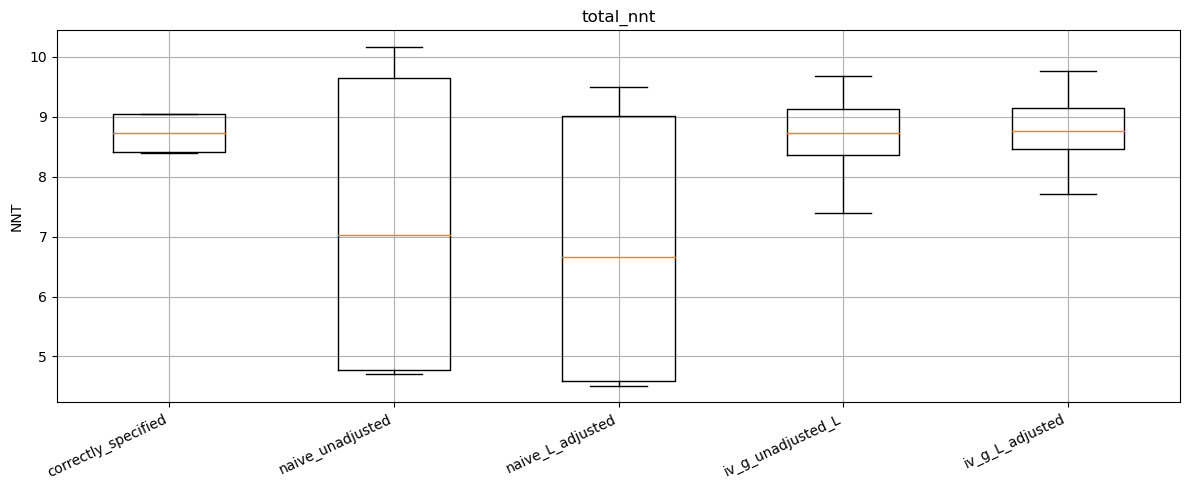

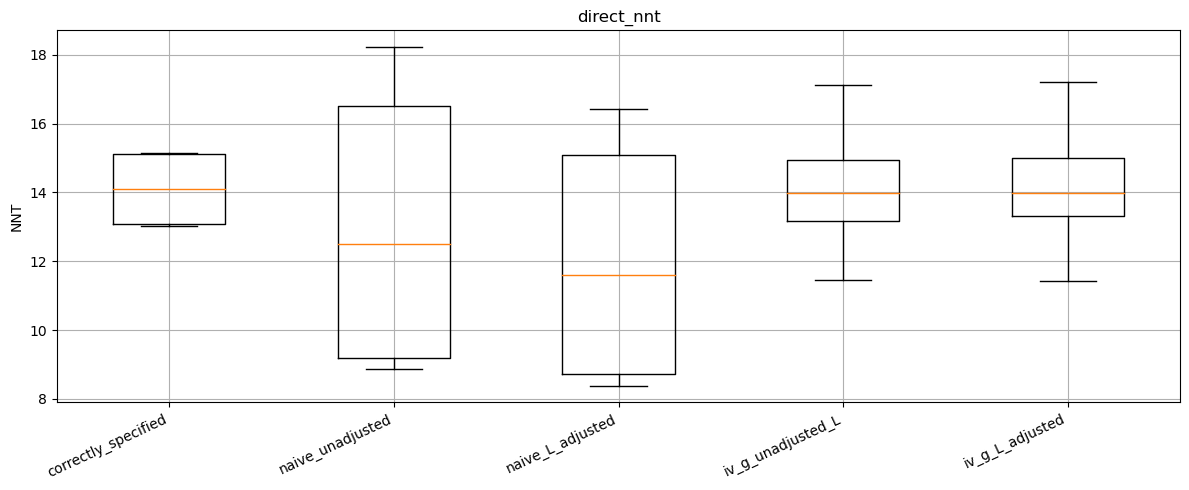

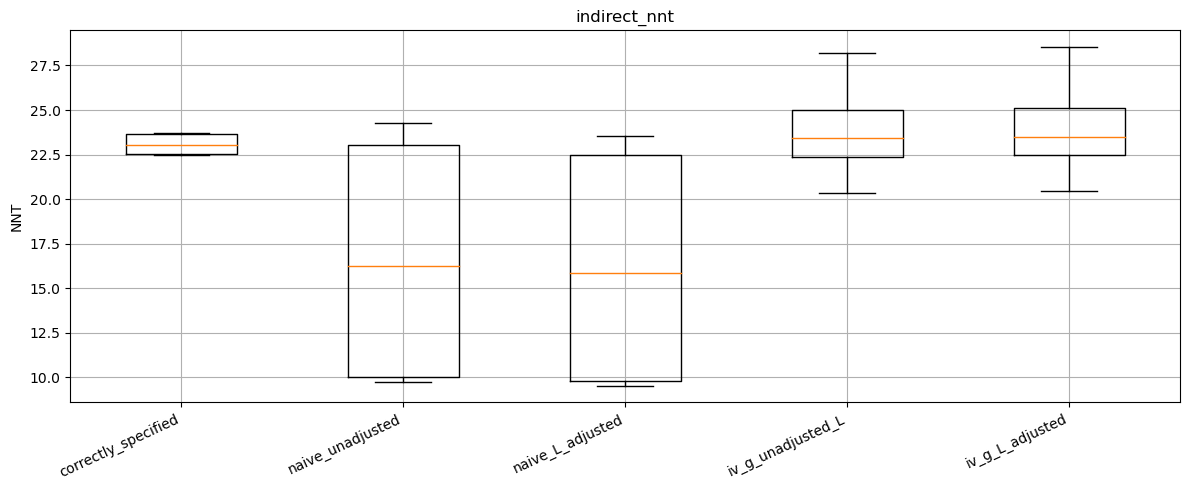

In [9]:
# Plot NNT distributions. Extreme NNT values can happen when an estimated RD is close to zero,
# so the plot clips the y-axis for readability.
plot_df = results.melt(
    id_vars=["scenario", "rep", "estimator"],
    value_vars=["total_nnt", "direct_nnt", "indirect_nnt"],
    var_name="quantity",
    value_name="nnt"
).replace([np.inf, -np.inf], np.nan).dropna()

for quantity in ["total_nnt", "direct_nnt", "indirect_nnt"]:
    subset = plot_df[plot_df["quantity"] == quantity]
    labels = ["correctly_specified", "naive_unadjusted", "naive_L_adjusted", "iv_g_unadjusted_L", "iv_g_L_adjusted"]
    data = [subset.loc[subset["estimator"] == lab, "nnt"].values for lab in labels]
    plt.figure(figsize=(12, 5))
    plt.boxplot(data, labels=labels, showfliers=False)
    plt.title(quantity)
    plt.ylabel("NNT")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

## Conclusion

The simulation examines whether the estimators recover the total, direct, and indirect risk-difference effects under two scenarios:

$$
\text{Scenario 1: } U \text{ has no effect},
$$

$$
\text{Scenario 2: } U \text{ confounds } A,\ M,\ \text{and }Y.
$$

When all relevant confounding is measured, \(L\)-adjusted G-computation should recover the causal effects well. When \(U\) is active but unobserved, naive G-computation may be biased even after adjustment for \(L\).

The two-instrument G-estimation prototype uses \(Z_1\) and \(Z_2\) to estimate treatment and mediator blips while retaining \(L\) in the nuisance models. Its performance is evaluated by comparing

$$
\widehat{RD}_{\mathrm{total}},
\qquad
\widehat{RD}_{\mathrm{direct}},
\qquad
\widehat{RD}_{\mathrm{indirect}},
$$

with their DGM-based Monte Carlo values.

For every estimator, the final NNT quantities are transformations of the risk differences:

$$
\widehat{NNT}_k
=
\frac{1}{\widehat{RD}_k}.
$$

Accordingly, interpretation should focus first on the risk differences, especially when an estimated effect is close to zero, because reciprocation can produce very large or unstable NNT values.
